# Trening modelu oceny stylu jazdy (ExtraTrees)
Poniższy kod realizuje proces wczytywania sekwencji z sieci CAN, ekstrakcji cech w oknach czasowych, nadawania etykiet przy użyciu stworzonych reguł (pseudoetykiety) oraz trenowania modelu `ExtraTreesClassifier` do klasyfikacji stylów jazdy. Model na końcu eksportowany jest z użyciem `emlearn` do wbudowania w platformę ESP32.

In [11]:
import os
import glob
import json
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler

import emlearn

DATA_GLOB = "data/*.csv"
OUT_DIR = "prepared_data"
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_ORDER = ["normal", "eco", "aggressive"]

WIN_SEC = 3.0
STEP_SEC = 0.5
TARGET_HZ = 10.0
WIN_N = int(WIN_SEC * TARGET_HZ)
STEP_N = int(STEP_SEC * TARGET_HZ)

## 1. Wczytanie i czyszczenie danych
Ujednolicamy timestampy, odrzucamy momenty kiedy silnik był zgaszony (`ignition == 0`) lub auto cofało (`rear_gear == 1`). Wyliczamy również przyspieszenie (a) oraz szarpnięcie (jerk). Data próbkowania jest domyślnie ustalona do maksymalnie 10Hz na podstawie limitów danych dostarczanych z sieci.

In [12]:
def load_one_csv(path):
    df = pd.read_csv(path)
    
    needed = ["timestamp", "ignition", "speed", "rpm", "throttle", "brake", "rear_gear"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}")

    for c in needed:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=needed).copy()
    df = df.sort_values("timestamp")
    df = df.drop_duplicates(subset=["timestamp"], keep="first")

    df = df[(df["ignition"] == 1) & (df["rear_gear"] == 0)].copy()
    df = df[df["speed"] >= 0].copy()

    dt = df["timestamp"].diff() / 1000.0
    dt = dt.clip(lower=0.05, upper=0.30).fillna(0.10)

    df["dt"] = dt
    df["a_ms2"] = (df["speed"].diff() / 3.6) / df["dt"]
    df["a_ms2"] = df["a_ms2"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    df["jerk_ms3"] = df["a_ms2"].diff() / df["dt"]
    df["jerk_ms3"] = df["jerk_ms3"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    df["d_throttle_s"] = df["throttle"].diff() / df["dt"]
    df["d_throttle_s"] = df["d_throttle_s"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    df["d_brake_s"] = df["brake"].diff() / df["dt"]
    df["d_brake_s"] = df["d_brake_s"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    df["source_file"] = os.path.basename(path)
    return df.reset_index(drop=True)

files = sorted(glob.glob(DATA_GLOB))
trips = [load_one_csv(p) for p in files]
raw_all = pd.concat(trips, ignore_index=True)

print("Liczba plikow:", len(files))
print("Liczba wierszy po czyszczeniu:", len(raw_all))
raw_all.head()

Liczba plikow: 29
Liczba wierszy po czyszczeniu: 477061


,timestamp,ignition,speed,rpm,throttle,brake,fuel_level,fuel_cons,distance,range,oil_temp,esp,rear_gear,dt,a_ms2,jerk_ms3,d_throttle_s,d_brake_s,source_file
0,97343,1,0,0,0,0,28,0.00,146330,148,42,0,0,0.100,0.0,0.0,0.0,0.000000,20260404_091932.csv
1,97465,1,0,0,0,1,28,0.00,146330,148,42,0,0,0.122,0.0,0.0,0.0,8.196721,20260404_091932.csv
2,128394,1,0,1369,0,0,28,6.13,146330,145,43,0,0,0.300,0.0,0.0,0.0,-3.333333,20260404_091932.csv
3,128494,1,0,1369,0,0,28,6.13,146330,145,43,0,0,0.100,0.0,0.0,0.0,0.000000,20260404_091932.csv
4,128593,1,0,1368,0,0,28,7.15,146330,145,43,0,0,0.099,0.0,0.0,0.0,0.000000,20260404_091932.csv


## 2. Okna czasowe
Pojedyncza inferencja modelu odbywa się dla całych fragmentów trasy. Stosujemy technikę przesuwnych okien czasowych (w wielkości `WIN_SEC` sekund) przesuniętych w czasie o `STEP_SEC` do minimalizacji opóźnień między wyznaczeniem kolejnego parametru. Wynikowe wartości odzwierciedlają średnie zachowanie z przejazdów.

In [13]:
def make_window_features(df, win_n=WIN_N, step_n=STEP_N):
    rows = []
    if len(df) < win_n:
        return pd.DataFrame()

    for start in range(0, len(df) - win_n + 1, step_n):
        w = df.iloc[start:start + win_n]

        # Skip stop windows — handled as "normal" directly in MCU firmware
        if w["speed"].mean() < 2.0:
            continue

        feat = {
            "source_file": w["source_file"].iloc[-1],
            "ts_end": int(w["timestamp"].iloc[-1]),

            "speed_mean": w["speed"].mean(),
            "speed_std": w["speed"].std(ddof=0),
            "speed_p95": np.percentile(w["speed"], 95),

            "rpm_mean": w["rpm"].mean(),
            "rpm_std": w["rpm"].std(ddof=0),
            "rpm_p95": np.percentile(w["rpm"], 95),

            "throttle_mean": w["throttle"].mean(),
            "throttle_std": w["throttle"].std(ddof=0),
            "throttle_p95": np.percentile(w["throttle"], 95),
            "throttle_dp95": np.percentile(w["d_throttle_s"], 95),

            "brake_mean": w["brake"].mean(),
            "brake_p95": np.percentile(w["brake"], 95),
            "brake_dp95": np.percentile(w["d_brake_s"], 95),

            "a_mean": w["a_ms2"].mean(),
            "a_std": w["a_ms2"].std(ddof=0),
            "a_p95": np.percentile(w["a_ms2"], 95),
            "a_p05": np.percentile(w["a_ms2"], 5),
            "abs_a_mean": np.abs(w["a_ms2"]).mean(),

            "jerk_abs_mean": np.abs(w["jerk_ms3"]).mean(),
            "jerk_abs_p95": np.percentile(np.abs(w["jerk_ms3"]), 95),
        }
        rows.append(feat)

    return pd.DataFrame(rows)

windows = []
for t in trips:
    wf = make_window_features(t)
    if len(wf):
        windows.append(wf)

feat_df = pd.concat(windows, ignore_index=True)
print("Liczba okien:", len(feat_df))
feat_df.head()

Liczba okien: 88282


,source_file,ts_end,speed_mean,speed_std,speed_p95,rpm_mean,rpm_std,rpm_p95,throttle_mean,throttle_std,...,brake_mean,brake_p95,brake_dp95,a_mean,a_std,a_p95,a_p05,abs_a_mean,jerk_abs_mean,jerk_abs_p95
0,20260404_091932.csv,137647,2.800000,3.409790,8.0,1223.933333,83.082262,1348.55,1.800000,6.101366,...,0.0,0.0,0.0,0.692846,1.529457,3.207672,0.0,0.692846,8.454922,38.960909
1,20260404_091932.csv,138192,4.166667,3.652244,8.0,1207.333333,65.672081,1305.80,7.333333,13.272361,...,0.0,0.0,0.0,0.705383,1.661846,3.207672,0.0,0.863661,11.548605,41.804686
2,20260404_091932.csv,138745,5.666667,3.476908,9.0,1209.166667,67.134235,1299.20,16.333333,21.237284,...,0.0,0.0,0.0,0.783851,1.682139,3.207672,0.0,0.942129,13.170521,41.804686
3,20260404_091932.csv,139284,7.266667,2.606829,10.0,1241.566667,106.217602,1450.15,26.433333,25.124601,...,0.0,0.0,0.0,0.871203,1.707023,3.207672,0.0,1.029481,14.876930,41.804686
4,20260404_091932.csv,139792,8.700000,1.417745,11.0,1309.266667,166.940295,1616.55,35.400000,24.319539,...,0.0,0.0,0.0,0.647994,1.334076,2.935155,0.0,0.806271,12.845767,37.084278


## 3. Pseudo-etykiety (Reguły decyzyjne)
Na bazie zebranych cech konstruujemy etykiety decyzyjne (`normal`, `eco`, `aggressive`). Następnie rozdzielamy otrzymany zbiór na warstwę testową i treningową oraz skalujemy do 16 bitów. Użycie `GroupShuffleSplit` pomaga unikać przenikania "czasowego" danych podczas trenowania.

In [ ]:
def pseudo_label(row):
    aggr_points = 0
    aggr_points += int(row["a_p95"] > 2.0)
    aggr_points += int(row["a_p05"] < -2.2)
    aggr_points += int(row["jerk_abs_p95"] > 28.0)
    aggr_points += int(row["throttle_dp95"] > 120.0)
    aggr_points += int(row["brake_p95"] > 180.0)

    if aggr_points >= 3:
        return "aggressive"

    eco_points = 0
    eco_points += int(row["abs_a_mean"] < 0.45)
    eco_points += int(row["jerk_abs_mean"] < 0.9)
    eco_points += int(row["throttle_mean"] < 22.0)
    eco_points += int(row["brake_mean"] < 20.0)
    eco_points += int(row["rpm_mean"] < 2800.0)
    eco_points += int((row["speed_mean"] >= 20.0) and (row["speed_mean"] <= 95.0))

    # Engine braking: throttle released, coasting, no brake pressed.
    engine_braking = (
        row["throttle_mean"] < 2.0
        and row["brake_mean"] < 30.0
        and row["a_mean"] < -0.15
        and row["speed_mean"] > 10.0
    )
    if engine_braking:
        eco_points += 3

    if eco_points >= 5:
        return "eco"
    return "normal"

feat_df["label"] = feat_df.apply(pseudo_label, axis=1)
print(feat_df["label"].value_counts())

feature_cols = [c for c in feat_df.columns if c not in ["source_file", "ts_end", "label"]]
X = feat_df[feature_cols].copy()
y = feat_df["label"].copy()
groups = feat_df["source_file"].copy()

split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(split.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

quantizer = MinMaxScaler(feature_range=(-30000, 30000), clip=True)
X_train_q = np.rint(quantizer.fit_transform(X_train)).astype(np.int16)
X_test_q = np.rint(quantizer.transform(X_test)).astype(np.int16)

label
normal        69488
eco           11850
aggressive     6944
Name: count, dtype: int64


## 4. Trenowanie Modelu
Stosujemy model `ExtraTreesClassifier` z ograniczeniami pod architekturę wbudowaną: `n_estimators=60` i `max_depth=7` (zmniejszone z 80/8) — redukuje rozmiar eksportowanego pliku `.h` o ~25% przy minimalnej stracie dokładności.

In [15]:
model = ExtraTreesClassifier(
    n_estimators=60,   # reduced from 80 — smaller .h export (~25% less flash)
    max_depth=7,       # reduced from 8 — marginal accuracy loss, less overfitting
    min_samples_leaf=12,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_q, y_train)
y_pred = model.predict(X_test_q)

print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))
print("Macro F1:", round(f1_score(y_test, y_pred, average="macro"), 4))
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix [normal, eco, aggressive]:")
print(confusion_matrix(y_test, y_pred, labels=CLASS_ORDER))

Balanced accuracy: 0.8977
Macro F1: 0.7184
              precision    recall  f1-score   support

  aggressive     0.4448    0.9477    0.6054      2141
         eco     0.5300    0.9867    0.6896      3844
      normal     0.9929    0.7587    0.8601     24310

    accuracy                         0.8010     30295
   macro avg     0.6559    0.8977    0.7184     30295
weighted avg     0.8954    0.8010    0.8205     30295

Confusion matrix [normal, eco, aggressive]:
[[18444  3336  2530]
 [   48  3793     3]
 [   84    28  2029]]


## 5. Cross-walidacja (GroupKFold)
Weryfikujemy stabilność modelu na 5 foldach, gdzie każdy fold zawiera inne trasy (pliki). Niskie odchylenie standardowe potwierdza, że wyniki nie są artefaktem jednego podziału.

In [16]:
from sklearn.model_selection import GroupKFold

print("=== GroupKFold Cross-Validation (5 folds) ===\n")
gkf = GroupKFold(n_splits=5)

cv_bal_acc, cv_f1 = [], []

for fold_i, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups)):
    scaler_cv = MinMaxScaler(feature_range=(-30000, 30000), clip=True)
    X_tr_q = np.rint(scaler_cv.fit_transform(X.iloc[tr_idx])).astype(np.int16)
    X_va_q = np.rint(scaler_cv.transform(X.iloc[va_idx])).astype(np.int16)

    cv_model = ExtraTreesClassifier(
        n_estimators=60, max_depth=7, min_samples_leaf=12,
        max_features="sqrt", class_weight="balanced_subsample",
        random_state=42, n_jobs=-1
    )
    cv_model.fit(X_tr_q, y.iloc[tr_idx])
    y_va_pred = cv_model.predict(X_va_q)

    ba = balanced_accuracy_score(y.iloc[va_idx], y_va_pred)
    f1 = f1_score(y.iloc[va_idx], y_va_pred, average="macro")
    cv_bal_acc.append(ba)
    cv_f1.append(f1)
    print(f"Fold {fold_i + 1}: balanced_acc={ba:.4f}  macro_F1={f1:.4f}")

print(f"\nMean balanced_acc : {np.mean(cv_bal_acc):.4f} ± {np.std(cv_bal_acc):.4f}")
print(f"Mean macro_F1     : {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")

=== GroupKFold Cross-Validation (5 folds) ===

Fold 1: balanced_acc=0.9103  macro_F1=0.7303
Fold 2: balanced_acc=0.9054  macro_F1=0.7172
Fold 3: balanced_acc=0.8838  macro_F1=0.7055
Fold 4: balanced_acc=0.8568  macro_F1=0.6377
Fold 5: balanced_acc=0.8785  macro_F1=0.7047

Mean balanced_acc : 0.8870 ± 0.0194
Mean macro_F1     : 0.6991 ± 0.0321


## 6. Macierz pomyłek — wizualizacja
Lewa: liczba predykcji. Prawa: macierz znormalizowana wierszowo (recall per class) — pokazuje jak dobrze model odzyskuje każdą klasę.

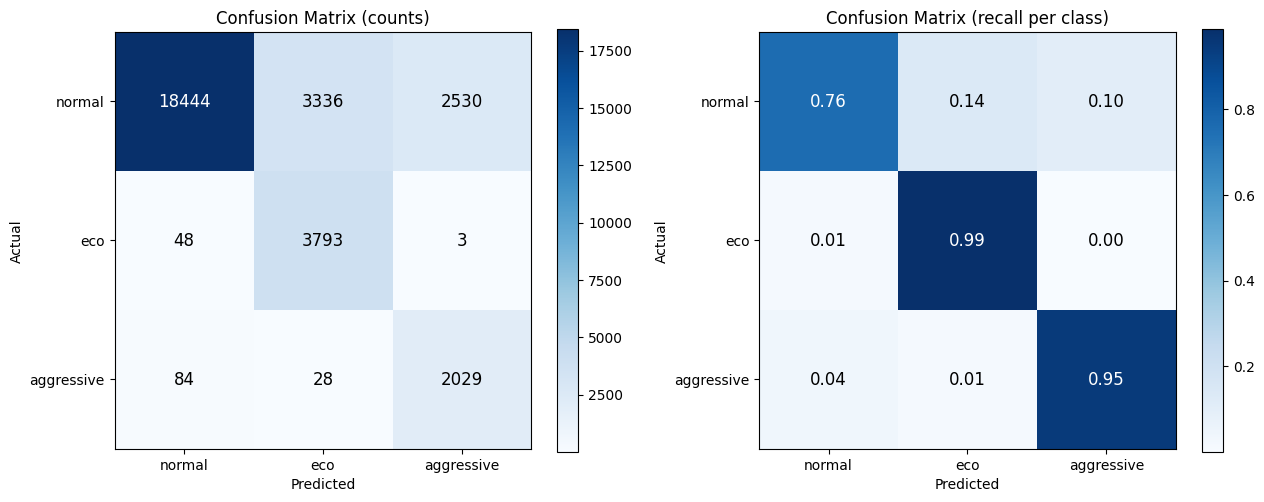

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    [".0f", ".2f"],
    ["Confusion Matrix (counts)", "Confusion Matrix (recall per class)"]
):
    im = ax.imshow(data, cmap="Blues")
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_yticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER)
    ax.set_yticklabels(CLASS_ORDER)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(len(CLASS_ORDER)):
        for j in range(len(CLASS_ORDER)):
            ax.text(j, i, format(data[i, j], fmt),
                    ha="center", va="center", fontsize=12,
                    color="white" if data[i, j] > data.max() * 0.5 else "black")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 7. Analiza rozkładów cech — błędne predykcje
Badamy rozkłady cech dla okien błędnie sklasyfikowanych przez model, w szczególności:
- `normal` → `eco` (3068 przypadków)
- `normal` → `aggressive` (2530 przypadków)

Pozwala to oceniç, czy granica decyzyjna pseudo-etykiet jest zbyt permisywna lub czy cechy nie separują klas wystarczająco.

=== Sample counts ===
  normal->normal (ok): 18444
  normal->eco (FP): 3336
  normal->aggressive (FP): 2530

=== Median feature values per group ===
                         abs_a_mean  jerk_abs_mean  jerk_abs_p95  throttle_mean  throttle_dp95  brake_mean  brake_p95     a_p95     a_p05    a_mean     rpm_mean  speed_mean
normal->normal (ok)        0.245751       4.362636     24.163505      87.333333      19.049098         0.0        0.0  1.107085  0.000000  0.078769  3163.783333  115.200000
normal->eco (FP)           0.265128       4.371739     23.814967      24.600000      19.090508         0.0        0.0  0.000000 -1.688355 -0.160302  2034.666667   65.533333
normal->aggressive (FP)    0.664603      10.768033     32.356424      69.016667      51.959115         0.0        0.0  2.525253 -1.317050  0.189433  2450.900000   61.766667


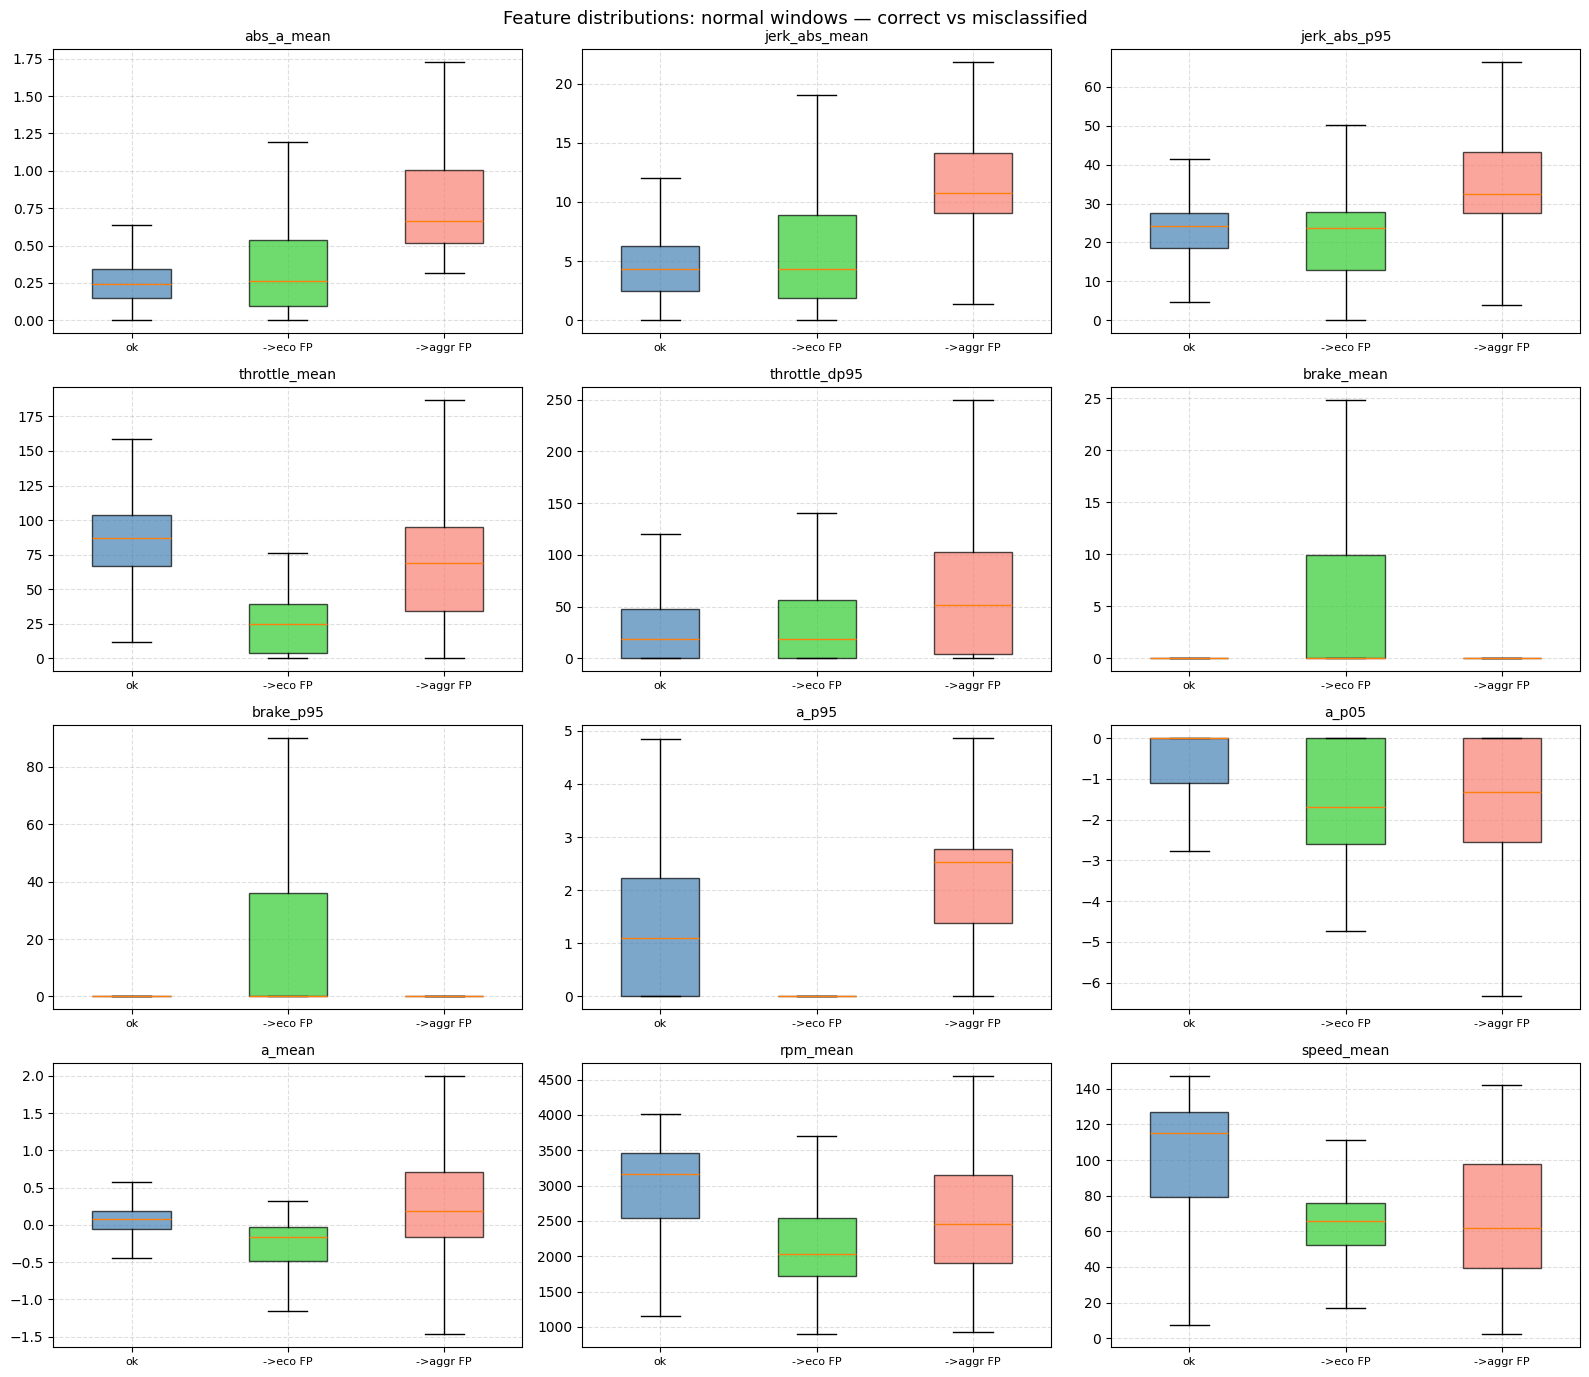


=== normal->eco FP — feature percentiles (25/50/75) ===
     abs_a_mean  jerk_abs_mean  jerk_abs_p95  throttle_mean  throttle_dp95  brake_mean  brake_p95  a_p95     a_p05    a_mean     rpm_mean  speed_mean
25%    0.095456       1.851852     12.838469       4.091667       0.000000    0.000000        0.0    0.0 -2.598707 -0.480670  1714.700000   52.233333
50%    0.265128       4.371739     23.814967      24.600000      19.090508    0.000000        0.0    0.0 -1.688355 -0.160302  2034.666667   65.533333
75%    0.536072       8.926568     27.777778      39.208333      56.381326    9.933333       36.0    0.0  0.000000 -0.032033  2543.425000   75.866667

=== normal->aggressive FP — feature percentiles (25/50/75) ===
     abs_a_mean  jerk_abs_mean  jerk_abs_p95  throttle_mean  throttle_dp95  brake_mean  brake_p95     a_p95     a_p05    a_mean     rpm_mean  speed_mean
25%    0.519593       9.026759     27.536285      33.908333       4.700855         0.0        0.0  1.376376 -2.539488 -0.16523

In [22]:
import matplotlib.pyplot as plt

# Build test dataframe with true/predicted labels and raw (unquantized) feature values
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = y_pred

# Misclassification groups for the dominant class (normal)
mask_norm_true = test_df["y_true"] == "normal"
mask_norm_ok   = mask_norm_true & (test_df["y_pred"] == "normal")
mask_norm_eco  = mask_norm_true & (test_df["y_pred"] == "eco")
mask_norm_aggr = mask_norm_true & (test_df["y_pred"] == "aggressive")

groups_masks = {
    "normal->normal (ok)":     mask_norm_ok,
    "normal->eco (FP)":        mask_norm_eco,
    "normal->aggressive (FP)": mask_norm_aggr,
}

# Features most relevant to pseudo-label decision rules
KEY_FEATURES = [
    "abs_a_mean", "jerk_abs_mean", "jerk_abs_p95",
    "throttle_mean", "throttle_dp95",
    "brake_mean", "brake_p95",
    "a_p95", "a_p05", "a_mean",
    "rpm_mean", "speed_mean",
]

print("=== Sample counts ===")
for name, mask in groups_masks.items():
    print(f"  {name}: {mask.sum()}")

print("\n=== Median feature values per group ===")
stats = {name: test_df.loc[mask, KEY_FEATURES].median() for name, mask in groups_masks.items()}
print(pd.DataFrame(stats).T.to_string())

# Box plots — 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
colors = ["steelblue", "limegreen", "salmon"]
group_labels = ["ok", "->eco FP", "->aggr FP"]

for ax, feat in zip(axes, KEY_FEATURES):
    data = [test_df.loc[mask, feat].values for mask in groups_masks.values()]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.5)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=10)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(group_labels, fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

for ax in axes[len(KEY_FEATURES):]:
    ax.set_visible(False)

plt.suptitle("Feature distributions: normal windows — correct vs misclassified", fontsize=13)
plt.tight_layout()
plt.show()

# Percentile breakdown for false positives
for name, mask in [("normal->eco FP", mask_norm_eco), ("normal->aggressive FP", mask_norm_aggr)]:
    print(f"\n=== {name} — feature percentiles (25/50/75) ===")
    print(test_df.loc[mask, KEY_FEATURES].describe().loc[["25%", "50%", "75%"]].to_string())

# Overlap check: how many FP windows would PASS pseudo-label thresholds?
print("\n=== Pseudo-label threshold overlap for normal->eco FP windows ===")
fp = test_df.loc[mask_norm_eco]
print(f"  abs_a_mean < 0.45:      {(fp['abs_a_mean'] < 0.45).mean():.1%}")
print(f"  jerk_abs_mean < 0.9:    {(fp['jerk_abs_mean'] < 0.9).mean():.1%}")
print(f"  throttle_mean < 22:     {(fp['throttle_mean'] < 22.0).mean():.1%}")
print(f"  brake_mean < 20:        {(fp['brake_mean'] < 20.0).mean():.1%}")
print(f"  rpm_mean < 2800:        {(fp['rpm_mean'] < 2800.0).mean():.1%}")
print(f"  speed_mean in [20,95]:  {((fp['speed_mean']>=20)&(fp['speed_mean']<=95)).mean():.1%}")

print("\n=== Pseudo-label threshold overlap for normal->aggressive FP windows ===")
fa = test_df.loc[mask_norm_aggr]
print(f"  a_p95 > 1.8:            {(fa['a_p95'] > 1.8).mean():.1%}")
print(f"  a_p05 < -2.2:           {(fa['a_p05'] < -2.2).mean():.1%}")
print(f"  jerk_abs_p95 > 28.0:     {(fa['jerk_abs_p95'] > 28.0).mean():.1%}")
print(f"  throttle_dp95 > 120:    {(fa['throttle_dp95'] > 120.0).mean():.1%}")
print(f"  brake_p95 > 180:        {(fa['brake_p95'] > 180.0).mean():.1%}")


## 7. Eksport rozwiązania do ESP32
Model zamieniany jest za pomocą `emlearn` na statycznie kompilowalny nagłówek C. Zapisujemy też meta dane o sposobie kwantyzacji wejścia na wartości od -30000 do 30000 w celu odtworzenia skalowania na mikrokontrolerze bez operacji zmiennoprzecinkowych. Zrzucamy to bezpośrednio do folderu `prepared_data/`.

**Schemat punktacji na ESP32** (sugestia):
- okno `eco` → `+2` punkty
- okno `normal` → `0` punktów
- okno `aggressive` → `-3` punkty

In [19]:
feat_df.to_csv(os.path.join(OUT_DIR, "windows_features_labeled.csv"), index=False)

fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)
fi.to_csv(os.path.join(OUT_DIR, "feature_importance_extratrees.csv"), index=False)

cmodel = emlearn.convert(
    model,
    method="inline",
    dtype="int16_t",
    leaf_bits=6
)
cmodel.save(
    file=os.path.join(OUT_DIR, "eco_model.h"),
    name="eco_model"
)

q_meta = {
    "feature_order": feature_cols,
    "scale": quantizer.scale_.tolist(),
    "min": quantizer.min_.tolist(),
    "class_order": CLASS_ORDER
}
with open(os.path.join(OUT_DIR, "feature_quantizer.json"), "w", encoding="utf-8") as f:
    json.dump(q_meta, f, indent=2)

print("Zakonczone. Model i dane zapisane w `prepared_data`.")

Zakonczone. Model i dane zapisane w `prepared_data`.


## 8. Wizualizacja nadanych etykiet
Wizualizacja pozwala nałożenie wygenerowanych pseudoetykiet (`normal`, `eco`, `aggressive`) na przebiegi surowych sygnałów z magistrali CAN (prędkość, gaz, hamulec) w czasie dla wybranego pliku z przejazdem. Dzięki temu weryfikujemy czy reguły poprawnie łapią zamierzone momenty (np. nagłe przyspieszenia jako agresywne, płynną jazdę jako eco).

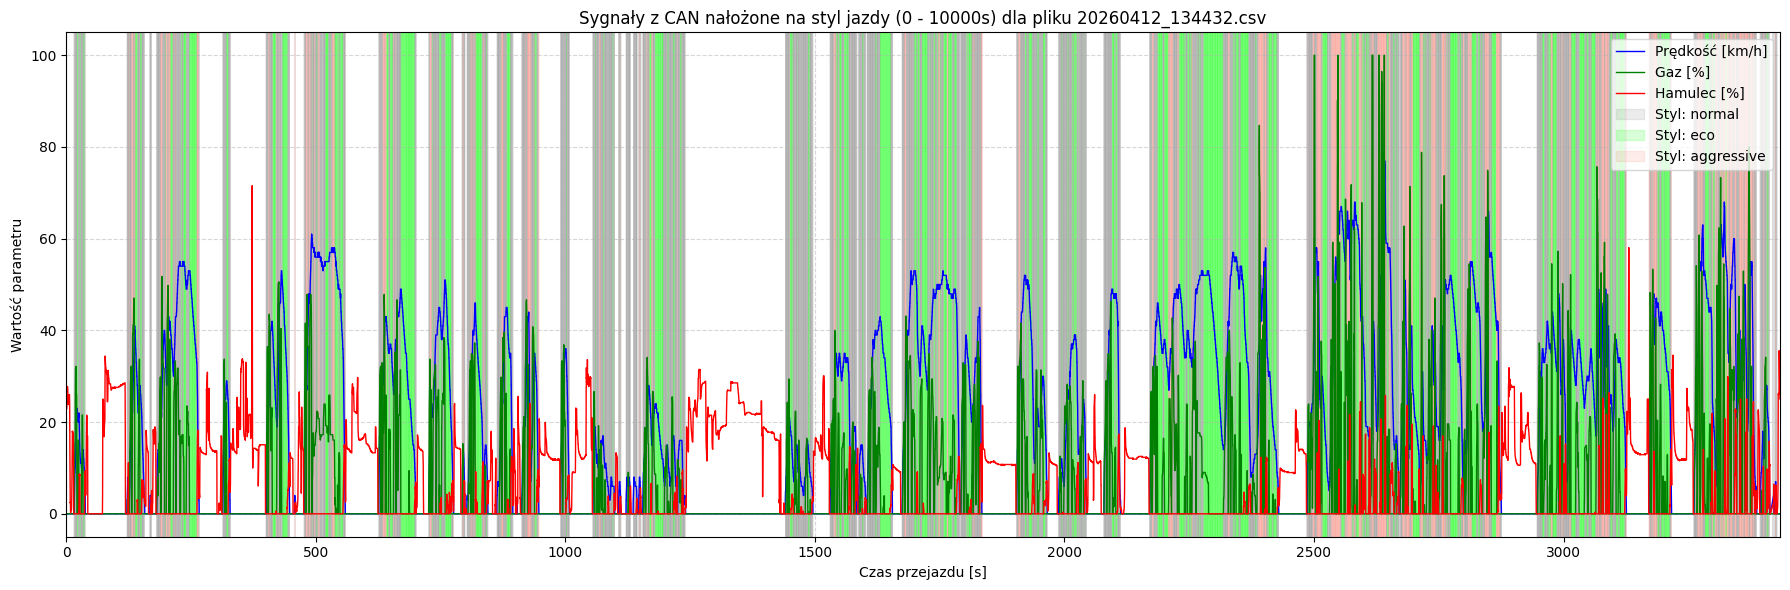

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Pobieramy pierwszy z wczytanych przejazdów dla przykładu
sample_file = feat_df["source_file"].unique()[19]

# Wyciągamy dane
df_raw = raw_all[raw_all["source_file"] == sample_file].copy()
df_labels = feat_df[feat_df["source_file"] == sample_file].copy()

# Ustawiamy oś czasu w sekundach
t0 = df_raw["timestamp"].min()
df_raw["time_s"] = (df_raw["timestamp"] - t0) / 1000.0
df_labels["time_s"] = (df_labels["ts_end"] - t0) / 1000.0

# Ograniczenie wielkości okna do pierwszych 500 sekund (dla czytelności)
MAX_TIME = 10000.0
df_raw = df_raw[df_raw["time_s"] <= MAX_TIME]
df_labels = df_labels[df_labels["time_s"] <= MAX_TIME]

# Przeskalowanie sygnałów pedałów do 0-100% na potrzeby wizualizacji
# Przepustnica: 0-255 -> 0-100%, Hamulec: 0-1023 (0x3FF) -> 0-100%
df_raw["throttle_pct"] = df_raw["throttle"] / 2.55
df_raw["brake_pct"] = df_raw["brake"] / 10.23

fig, ax1 = plt.subplots(figsize=(18, 6))

# Rysowanie cienkich linii dla surowych sygnałów
ax1.plot(df_raw["time_s"], df_raw["speed"], color="blue", linewidth=1.0, label="Prędkość [km/h]")
ax1.plot(df_raw["time_s"], df_raw["throttle_pct"], color="green", linewidth=1.0, label="Gaz [%]")
ax1.plot(df_raw["time_s"], df_raw["brake_pct"], color="red", linewidth=1.0, label="Hamulec [%]")

# Mapa kolorów dla tła (etykiet). Używamy szarego dla normalnej jazdy, żeby nie zaburzał wykresu.
color_map = {"normal": "gray", "eco": "lime", "aggressive": "salmon"}

# Rysowanie tła (obszarów) dla przypisanych etykiet
# Okno u nas kończy się ts_end i trwa domyślnie WIN_SEC sekund.
for _, row in df_labels.iterrows():
    t_end = row["time_s"]
    t_start = max(0, t_end - WIN_SEC)
    label = row["label"]
    color = color_map.get(label, "white")
    
    # Rysujemy półprzezroczysty prostokąt, zmniejszone alpha dla większej przezroczystości
    ax1.axvspan(t_start, t_end, color=color, alpha=0.15, lw=0)

# Budowanie połączonej legendy (dla linii i dla teł)
lines, line_labels = ax1.get_legend_handles_labels()
bg_patches = [mpatches.Patch(color=color_map[k], alpha=0.15, label=f"Styl: {k}") for k in color_map]

ax1.legend(handles=lines + bg_patches, loc="upper right")
ax1.set_xlabel("Czas przejazdu [s]")
ax1.set_ylabel("Wartość parametru")
ax1.set_title(f"Sygnały z CAN nałożone na styl jazdy (0 - {int(MAX_TIME)}s) dla pliku {sample_file}")
ax1.grid(True, linestyle="--", alpha=0.5)

plt.xlim(0, df_raw["time_s"].max())
plt.tight_layout()
plt.show()